In [4]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
sns.set(style="darkgrid")
%matplotlib inline

In [5]:
df = pd.read_excel("custrandata.xlsx")

In [6]:
df.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[ns]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 32.1+ MB


**Data Preparation**

In [8]:
data = df[(df['Price'] > 0) & (df['Quantity']>0)]
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 511566 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      511566 non-null  object        
 1   StockCode    511566 non-null  object        
 2   Description  511566 non-null  object        
 3   Quantity     511566 non-null  int64         
 4   InvoiceDate  511566 non-null  datetime64[ns]
 5   Price        511566 non-null  float64       
 6   Customer ID  407664 non-null  float64       
 7   Country      511566 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(4)
memory usage: 35.1+ MB


In [9]:
data.drop_duplicates(inplace = True)
data = data.dropna(subset=['Customer ID'])
data['Description'] = data['Description'].str.lower()
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"record frame 7"" single size",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


In [10]:
data['Description'] = data['Description'].replace(to_replace=r'[^\w\s]', value='', regex=True) 

data = data.loc[data['StockCode'].astype(str).str[0:4].str.isdigit()]

data['month'] = data['InvoiceDate'].dt.month
data['year'] = data['InvoiceDate'].dt.year
data['WeekDay'] = data['InvoiceDate'].dt.day_name()
data['month_year'] = pd.to_datetime(data[['year', 'month']].assign(Day=1))
data['hour'] = data['InvoiceDate'].dt.hour
data.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,month,year,WeekDay,month_year,hour
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7
3,489434,22041,record frame 7 single size,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7


In [12]:
data['revenue'] = data['Price'] * data['Quantity']
data['freq'] = data.groupby('Customer ID')['Customer ID'].transform('count')

**RFM Analysis**

In [13]:
df_uk = data[data['Country'] == "United Kingdom"]
df_uk.head()

,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,month,year,WeekDay,month_year,hour,revenue,freq
0,489434,85048,15cm christmas glass ball 20 lights,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7,83.4,62
1,489434,79323P,pink cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7,81.0,62
2,489434,79323W,white cherry lights,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7,81.0,62
3,489434,22041,record frame 7 single size,48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7,100.8,62
4,489434,21232,strawberry ceramic trinket box,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,12,2009,Tuesday,2009-12-01,7,30.0,62


In [14]:
print(df_uk['InvoiceDate'].min())
print(df_uk['InvoiceDate'].max())

2009-12-01 07:45:00
2010-12-09 20:01:00


In [15]:
import datetime as dt
presence = dt.datetime(2011,12,10)
df_uk['InvoiceDate'] = pd.to_datetime(df_uk['InvoiceDate'])

In [16]:
rfm = df_uk.groupby('Customer ID').agg({'InvoiceDate': lambda x: (presence - x.max()).days, 'Invoice': lambda x: len(x), 'revenue': lambda x: x.sum()})
rfm['InvoiceDate'] = rfm['InvoiceDate'].astype(int)
rfm.rename(columns={'InvoiceDate': 'recency', 
                         'Invoice': 'frequency', 
                         'revenue': 'monetary_value'}, inplace=True)
rfm.head()

,recency,frequency,monetary_value
Customer ID,,,
12346.0,529,24,169.36
12608.0,404,16,415.79
12745.0,486,22,723.85
12746.0,540,17,254.55
12747.0,369,153,5061.03


In [17]:
quantiles = rfm.quantile(q=[0.25,0.5,0.75])
quantiles = quantiles.to_dict()
rfm_segments= rfm

In [18]:
def RClass(x,p,d):
    if x <= d[p][0.25]:
        return 1
    elif x <= d[p][0.50]:
        return 2
    elif x <= d[p][0.75]: 
        return 3
    else:
        return 4
    
def FMClass(x,p,d):
    if x <= d[p][0.25]:
        return 4
    elif x <= d[p][0.50]:
        return 3
    elif x <= d[p][0.75]: 
        return 2
    else:
        return 1

In [19]:
rfm_segments['R_Quartile'] = rfm_segments['recency'].apply(RClass, args=('recency',quantiles,))
rfm_segments['F_Quartile'] = rfm_segments['frequency'].apply(FMClass, args=('frequency',quantiles,))
rfm_segments['M_Quartile'] = rfm_segments['monetary_value'].apply(FMClass, args=('monetary_value',quantiles,))

In [21]:
rfm_segments['RFMClass'] = rfm_segments.R_Quartile.map(str) \
                            + rfm_segments.F_Quartile.map(str) \
                            + rfm_segments.M_Quartile.map(str)
rfm_segments.head()

,recency,frequency,monetary_value,R_Quartile,F_Quartile,M_Quartile,RFMClass
Customer ID,,,,,,,
12346.0,529,24,169.36,4,3,4,434
12608.0,404,16,415.79,2,4,3,243
12745.0,486,22,723.85,3,3,2,332
12746.0,540,17,254.55,4,4,4,444
12747.0,369,153,5061.03,1,1,1,111


In [22]:
rfm_segments.to_excel('RFMdata.xlsx')

In [23]:
rfm_segments['RFMClass'].unique()

array(['434', '243', '332', '444', '111', '211', '333', '221', '241',
       '433', '122', '344', '311', '423', '322', '242', '323', '232',
       '121', '343', '334', '321', '411', '123', '234', '312', '131',
       '133', '231', '342', '212', '244', '223', '144', '422', '233',
       '142', '222', '421', '112', '143', '134', '331', '443', '412',
       '432', '132', '424', '224', '341', '313', '324', '413', '213',
       '442', '113', '431', '141', '124', '441', '314'], dtype=object)

In [24]:
rfm_segments.head()

,recency,frequency,monetary_value,R_Quartile,F_Quartile,M_Quartile,RFMClass
Customer ID,,,,,,,
12346.0,529,24,169.36,4,3,4,434
12608.0,404,16,415.79,2,4,3,243
12745.0,486,22,723.85,3,3,2,332
12746.0,540,17,254.55,4,4,4,444
12747.0,369,153,5061.03,1,1,1,111


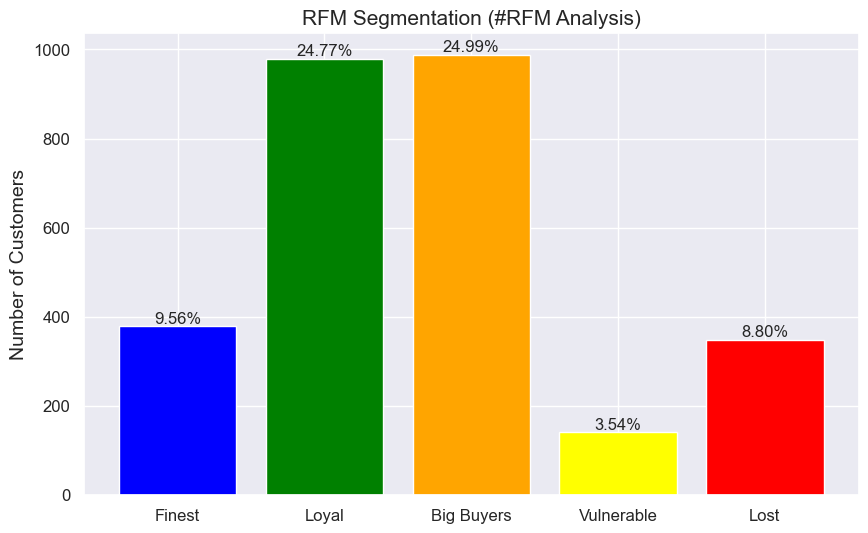

In [26]:
%matplotlib inline
import matplotlib.pyplot as plt

categories = ['Finest', 'Loyal', 'Big Buyers', 'Vulnerable', 'Lost']
counts = [
    len(rfm_segments[rfm_segments['RFMClass'] == '111']),
    len(rfm_segments[rfm_segments['F_Quartile'] == 1]),
    len(rfm_segments[rfm_segments['M_Quartile'] == 1]),
    len(rfm_segments[rfm_segments['RFMClass'] == '322']),
    len(rfm_segments[rfm_segments['RFMClass'] == '444'])
]
total_customers = len(rfm_segments)
percentages = [count / total_customers * 100 for count in counts]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.bar(categories, counts, color=['blue', 'green', 'orange', 'yellow', 'red'])

ax.set_ylabel('Number of Customers', fontsize=14)

for bar, count, percentage in zip(bars, counts, percentages):
    height = bar.get_height()
    ax.text(bar.get_x() + bar.get_width() / 2, height + 1, f'{percentage:.2f}%', ha='center', va='bottom', fontsize=12)

ax.set_title('RFM Segmentation (#RFM Analysis)', fontsize=15)

ax.tick_params(axis='both', which='major', labelsize=12)
plt.savefig('C:/Users/USER/Desktop/Analysis/rfm.jpg')

plt.show()